<h1 style='color:#5BC0EB; font-weight:800; font-size:1.9em; margin-bottom:0.3em'>
Mejoras al sistema adaptativo</h1>
<p style='color:#b0b0b0; font-size:1.05em'>
Reentrenamos el selector sobre datos de píxeles, construimos un ensemble ponderado, 
cuantificamos la incertidumbre entre escalas y simulamos una prueba con imagen escaneada real.</p>

In [1]:
import json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline
from scipy.optimize import curve_fit
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
warnings.filterwarnings('ignore')

%matplotlib inline

ROOT    = Path.cwd().parent
DATA_T  = ROOT / 'datos' / 'target'
DATA_P  = ROOT / 'datos' / 'pixel_curves'
MODELOS = ROOT / 'modelos'
ESCALAS = [10, 15, 25, 50, 100]

AZUL   = '#5BC0EB'
NARANJ = '#F18F01'
PAL    = '#A8D8EA'
VERDE  = '#2A9D8F'
ROJO   = '#E63946'
PALETTE_METODO = {'polinomio': AZUL, 'gaussianas': NARANJ, 'spline': VERDE}

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor':   '#111111',
    'axes.edgecolor':   '#444444',
    'axes.labelcolor':  '#b0b0b0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#b0b0b0',
    'grid.color':       '#333333',
    'grid.alpha':       0.25,
    'legend.framealpha': 0.25
})

In [2]:
def leer_target(cid):
    return pd.read_csv(DATA_T / f'curve_{cid:04d}.txt', header=None,
                       names=['x', 'y']).sort_values('x').reset_index(drop=True)

def leer_pixel_real(cid, escala):
    d = pd.read_csv(DATA_P / f'curve_{cid:04d}_X{escala}.txt',
                    sep=' ', header=None, names=['x', 'y'])
    f = escala / 10.0
    d['x'] = d['x'] / f
    d['y'] = d['y'] / f
    return d.sort_values('x').reset_index(drop=True)

def compute_pixel_features(dc):
    x = dc['x'].values.astype(float); y = dc['y'].values.astype(float); n = len(x)
    if n < 5: return {}
    dy_ = np.diff(y); yr = float(y.max() - y.min()); xr = float(x.max() - x.min())
    yf = np.abs(np.fft.rfft(y - y.mean())); fr = np.fft.rfftfreq(n); yf[0] = 0
    yfmax = yf.max()
    if yfmax > 0:
        tp = (yf**2).sum() + 1e-12
        cent = float((fr * yf**2).sum() / tp)
        pks, _ = find_peaks(yf, height=0.1*yfmax); nfp = float(len(pks))
    else:
        cent = nfp = 0.0
    W = max(5, n // 20); km = []
    for i in range(0, n - W, max(1, W // 2)):
        sx, sy = x[i:i+W], y[i:i+W]
        if len(sx) < 3: continue
        dy2 = np.gradient(sy, sx); d2 = np.gradient(dy2, sx)
        km.append(float(np.mean(np.abs(d2) / (1 + dy2**2)**1.5)))
    loc_comp = float(np.std(km)) if len(km) > 1 else 0.0
    pks_y, _ = find_peaks(y); vals_y, _ = find_peaks(-y)
    f = {'y_range': yr, 'x_range': xr, 'aspect_ratio': yr / (xr + 1e-9),
         'y_skewness': float(stats.skew(y)), 'y_kurtosis': float(stats.kurtosis(y)),
         'monotonicity_score': float((dy_ > 0).sum() / max(len(dy_), 1)),
         'local_complexity': loc_comp, 'fft_spectral_centroid': cent,
         'fft_n_peaks': nfp, 'n_maxima': float(len(pks_y)), 'n_minima': float(len(vals_y))}
    sl = np.diff(y) / (np.diff(x) + 1e-9)
    f['slope_mean']   = float(np.mean(np.abs(sl)))
    f['angle_range']  = float(np.ptp(np.arctan(sl)))
    f['n_inflection'] = float(np.sum(np.diff(np.sign(np.diff(y))) != 0))
    g1 = np.gradient(y, x); g2 = np.gradient(g1, x)
    curv = np.abs(g2) / (1 + g1**2)**1.5
    f['curvature_mean'] = float(np.mean(curv))
    f['curvature_max']  = float(np.max(curv))
    f['curvature_q95']  = float(np.quantile(curv, 0.95))
    return f

def _gauss_sum(x, *params):
    n = len(params) // 3; y = np.zeros_like(x, dtype=float)
    for i in range(n):
        A, mu, sig = params[3*i], params[3*i+1], params[3*i+2]
        y += A * np.exp(-(x - mu)**2 / (2 * sig**2 + 1e-9))
    return y

def fit_polinomio(xp, yp, x_eval, deg=10):
    deg = min(deg, len(xp) - 1)
    coef = np.polyfit(xp, yp, deg)
    return np.polyval(coef, x_eval)

def fit_spline(xp, yp, x_eval):
    xp_u, idx = np.unique(xp, return_index=True); yp_u = yp[idx]
    if len(xp_u) < 5: return fit_polinomio(xp, yp, x_eval, deg=6)
    s = UnivariateSpline(xp_u, yp_u, k=min(3, len(xp_u)-1), s=len(xp_u))
    return s(np.clip(x_eval, xp_u.min(), xp_u.max()))

def fit_gaussianas(xp, yp, x_eval, n_max=8):
    pks, _ = find_peaks(yp, height=yp.mean())
    n = min(max(len(pks), 1), n_max)
    p0 = []
    if len(pks):
        for pk in pks[:n]:
            p0 += [yp[pk], xp[pk], (xp[-1]-xp[0])/(4*n)]
    else:
        p0 = [yp.max(), xp.mean(), (xp[-1]-xp[0])/4]
    lo = [-np.inf]*len(p0); hi = [np.inf]*len(p0)
    try:
        popt, _ = curve_fit(_gauss_sum, xp, yp, p0=p0, bounds=(lo, hi),
                            maxfev=8000, method='trf')
        return _gauss_sum(x_eval, *popt)
    except Exception:
        return fit_spline(xp, yp, x_eval)

FITTERS = {'polinomio': fit_polinomio, 'spline': fit_spline, 'gaussianas': fit_gaussianas}

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / (ss_tot + 1e-12)

FEATS = [
    'y_range', 'x_range', 'aspect_ratio', 'y_skewness', 'y_kurtosis',
    'monotonicity_score', 'local_complexity', 'fft_spectral_centroid',
    'fft_n_peaks', 'n_maxima', 'n_minima', 'slope_mean', 'angle_range',
    'n_inflection', 'curvature_mean', 'curvature_max', 'curvature_q95'
]
print('Helpers cargados.')

Helpers cargados.


<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>
1. Reentrenar el selector sobre datos de pixeles</h2>
<p style='color:#b0b0b0'>
El selector original fue entrenado con las curvas target de alta precision. 
Cuando lo aplicamos sobre coordenadas de pixeles el ruido de digitalizacion infla descriptores como 
<code>fft_n_peaks</code> y <code>n_maxima</code>, lo que empuja al modelo a predecir gaussianas con mas 
frecuencia de la que corresponde. La solucion es reentrenarlo usando directamente los pixeles como entrada, 
de modo que aprenda a clasificar bajo las mismas condiciones en las que va a operar.</p>
<div style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); 
color:#e8c97a; padding:8px 14px; margin:8px 0'>
Idea clave: si el modelo va a ver pixeles en produccion, tiene que haber visto pixeles en entrenamiento.
</div>

<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>
1.1 Dataset de entrenamiento desde pixeles</h4>
<p style='color:#b0b0b0'>Para cada curva tomamos la escala X25 y calculamos los descriptores sobre 
esas coordenadas. La etiqueta la tomamos del selector original usando sus features propios (12), 
no los nuestros (17).</p>

In [3]:
_ck = joblib.load(MODELOS / 'modelo_seleccion_metodo.pkl')
selector_orig = _ck['pipeline']
FEATS_ORIG    = _ck['features']
CLASES        = _ck['classes']
print('Selector original cargado. Clases:', CLASES)
print(f'Features originales ({len(FEATS_ORIG)}): {FEATS_ORIG}')

ESCALA_TRAIN = 25
rows = []
for cid in range(1, 501):
    try:
        dp    = leer_pixel_real(cid, ESCALA_TRAIN)
        feats = compute_pixel_features(dp)
        if not feats: continue
        row_orig = np.array([feats.get(f, 0.0) for f in FEATS_ORIG]).reshape(1, -1)
        etiqueta = selector_orig.predict(row_orig)[0]
        feats['curva'] = cid
        feats['clase'] = etiqueta
        rows.append(feats)
    except FileNotFoundError:
        pass

df_px = pd.DataFrame(rows)
print(f'Dataset: {len(df_px)} muestras')
print(df_px['clase'].value_counts())

Selector original cargado. Clases: ['gaussianas', 'polinomio', 'spline']
Features originales (12): ['n_inflection', 'n_maxima', 'fft_n_peaks', 'aspect_ratio', 'slope_mean', 'curvature_max', 'angle_range', 'monotonicity_score', 'curvature_mean', 'curvature_q95', 'fft_spectral_centroid', 'y_range']
Dataset: 500 muestras
clase
gaussianas    343
spline         90
polinomio      67
Name: count, dtype: int64


<h4 style='color:#A8D8EA; font-family:sans-serif; font-weight:700'>
1.2 Entrenar el nuevo selector</h4>
<p style='color:#b0b0b0'>RandomForest con 5-fold estratificado. 
El nuevo modelo usa todos nuestros 17 descriptores de pixeles.</p>

In [4]:
X_px = df_px[FEATS].fillna(0).values
y_px = df_px['clase'].values

pipe_new = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=12,
                                   min_samples_leaf=3, random_state=42, n_jobs=-1))
])

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(pipe_new, X_px, y_px, cv=cv, scoring='accuracy')
print(f'CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}')

pipe_new.fit(X_px, y_px)
joblib.dump({'pipeline': pipe_new, 'features': FEATS, 'classes': CLASES},
            MODELOS / 'selector_pixel.pkl')
print('Guardado en modelos/selector_pixel.pkl')

CV accuracy: 0.9960 +/- 0.0049
Guardado en modelos/selector_pixel.pkl


            original  reentrenado
gaussianas     0.686        0.686
spline         0.180        0.180
polinomio      0.134        0.134


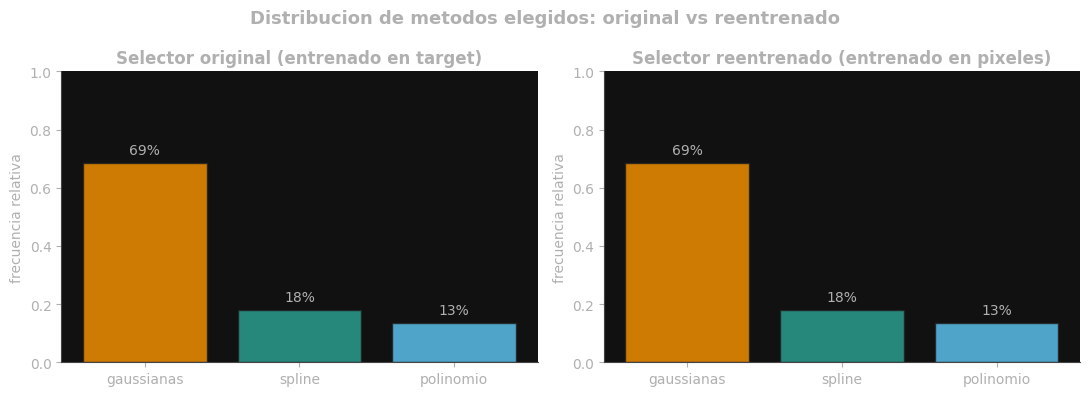

In [5]:
y_pred_new  = pipe_new.predict(X_px)
X_px_orig   = df_px[FEATS_ORIG].fillna(0).values
y_pred_orig = selector_orig.predict(X_px_orig)

dist_orig = pd.Series(y_pred_orig).value_counts(normalize=True).rename('original')
dist_new  = pd.Series(y_pred_new).value_counts(normalize=True).rename('reentrenado')
comp_dist = pd.concat([dist_orig, dist_new], axis=1).fillna(0).round(3)
print(comp_dist)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors_bar = [PALETTE_METODO.get(c, '#888888') for c in comp_dist.index]

for ax, col, titulo in zip(axes,
        ['original', 'reentrenado'],
        ['Selector original (entrenado en target)',
         'Selector reentrenado (entrenado en pixeles)']):
    bars = ax.bar(comp_dist.index, comp_dist[col], color=colors_bar, alpha=0.85, edgecolor='#222')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('frecuencia relativa')
    ax.set_ylim(0, 1)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, comp_dist[col]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.0%}',
                ha='center', va='bottom', fontsize=10)

fig.suptitle('Distribucion de metodos elegidos: original vs reentrenado',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
def predecir_metodo_pixel(xp, yp):
    raw = compute_pixel_features(pd.DataFrame({'x': xp, 'y': yp}))
    if not raw: return None, np.array([1/3, 1/3, 1/3])
    row = np.array([raw.get(f, 0.0) for f in FEATS]).reshape(1, -1)
    row = np.nan_to_num(row)
    probs = pipe_new.predict_proba(row)[0]
    k = int(np.argmax(probs))
    return pipe_new.classes_[k], probs

def reconstruir_pixel(cid, escala):
    dp  = leer_pixel_real(cid, escala)
    tgt = leer_target(cid)
    xp, yp  = dp['x'].values, dp['y'].values
    x_eval  = np.linspace(xp.min(), xp.max(), 300)
    metodo, probs = predecir_metodo_pixel(xp, yp)
    if metodo is None: metodo = 'spline'
    y_hat  = FITTERS[metodo](xp, yp, x_eval)
    y_tgt  = np.interp(x_eval, tgt['x'].values, tgt['y'].values)
    return {'cid': cid, 'escala': escala, 'metodo': metodo, 'probs': probs,
            'x_eval': x_eval, 'y_hat': y_hat, 'y_tgt': y_tgt,
            'r2': float(r2(y_tgt, y_hat))}

print('Funciones de prediccion y reconstruccion listas.')

Funciones de prediccion y reconstruccion listas.


In [ ]:
print('Evaluando 500 curvas x 5 escalas con el nuevo selector...')
results1 = []
for cid in range(1, 501):
    for esc in ESCALAS:
        try:
            rec = reconstruir_pixel(cid, esc)
            results1.append({'curva': cid, 'escala': esc,
                             'metodo': rec['metodo'], 'r2': rec['r2']})
        except Exception:
            pass

df1 = pd.DataFrame(results1)
fallos1 = (df1['r2'] < 0).sum()
print(f'Total: {len(df1)} registros')
print(f'R2 medio: {df1["r2"].mean():.4f}')
print(f'Fallos (R2<0): {fallos1} ({fallos1/len(df1)*100:.2f}%)')   
# 41 minutos 

Evaluando 500 curvas x 5 escalas con el nuevo selector...
Total: 1500 registros
R2 medio: 0.9589
Fallos (R2<0): 0 (0.00%)


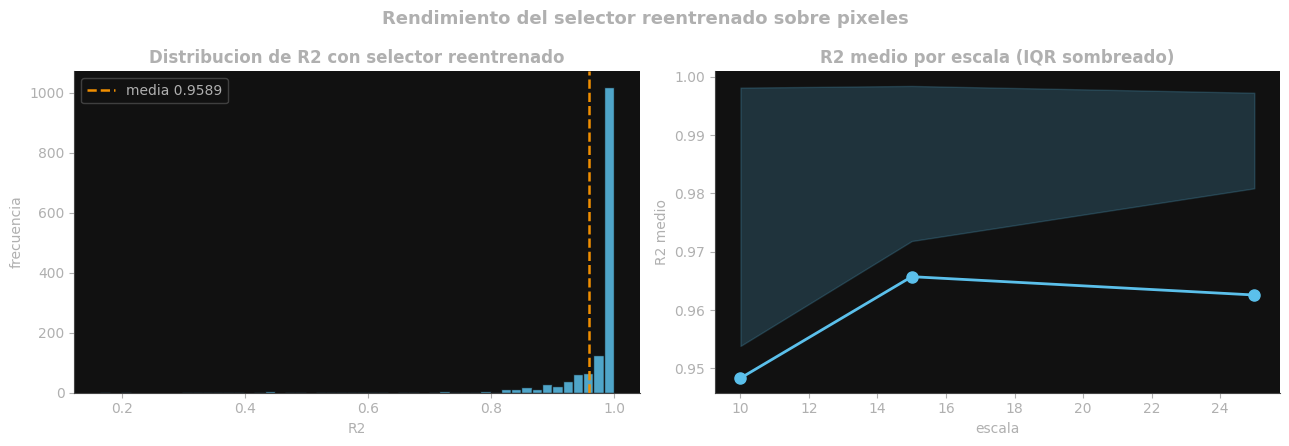

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(df1['r2'].clip(-0.5, 1), bins=50, color=AZUL, alpha=0.85, edgecolor='#111')
ax.axvline(df1['r2'].mean(), color=NARANJ, lw=1.8, linestyle='--',
           label=f'media {df1["r2"].mean():.4f}')
ax.set_xlabel('R2'); ax.set_ylabel('frecuencia')
ax.set_title('Distribucion de R2 con selector reentrenado', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
r2_by_esc = df1.groupby('escala')['r2'].mean()
ax.plot(r2_by_esc.index, r2_by_esc.values, 'o-', color=AZUL, lw=2, ms=8)
ax.fill_between(r2_by_esc.index,
                df1.groupby('escala')['r2'].quantile(0.25),
                df1.groupby('escala')['r2'].quantile(0.75),
                alpha=0.2, color=AZUL)
ax.set_xlabel('escala'); ax.set_ylabel('R2 medio')
ax.set_title('R2 medio por escala (IQR sombreado)', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Rendimiento del selector reentrenado sobre pixeles', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>
2. Ensemble ponderado por probabilidades</h2>
<p style='color:#b0b0b0'>
El selector elige un unico metodo. Pero cuando el modelo no esta seguro puede ser mejor 
combinar los tres ajustes ponderando por las probabilidades del clasificador.</p>
<div style='border-left:4px solid #5BC0EB; background:rgba(91,192,235,0.08); 
color:#A8D8EA; padding:8px 14px; margin:8px 0'>
y_ens = p_poly * y_poly + p_spline * y_spline + p_gauss * y_gauss
</div>

In [9]:
def reconstruir_ensemble(cid, escala):
    dp  = leer_pixel_real(cid, escala)
    tgt = leer_target(cid)
    xp, yp  = dp['x'].values, dp['y'].values
    x_eval  = np.linspace(xp.min(), xp.max(), 300)
    _, probs = predecir_metodo_pixel(xp, yp)
    classes_order = pipe_new.classes_
    prob_map = {c: p for c, p in zip(classes_order, probs)}
    y_ens = np.zeros(300)
    for metodo, fitter in FITTERS.items():
        w = prob_map.get(metodo, 0.0)
        if w < 1e-6: continue
        try:
            y_ens += w * fitter(xp, yp, x_eval)
        except Exception:
            pass
    y_tgt      = np.interp(x_eval, tgt['x'].values, tgt['y'].values)
    metodo_best = classes_order[int(np.argmax(probs))]
    return {'cid': cid, 'escala': escala, 'probs': prob_map, 'metodo_best': metodo_best,
            'x_eval': x_eval, 'y_ens': y_ens, 'y_tgt': y_tgt,
            'r2_ens': float(r2(y_tgt, y_ens))}

print('reconstruir_ensemble listo.')

reconstruir_ensemble listo.


In [ ]:
print('Evaluando ensemble en 500 curvas x 5 escalas...')
results2 = []
for cid in range(1, 501):
    for esc in ESCALAS:
        try:
            rec = reconstruir_ensemble(cid, esc)
            results2.append({'curva': cid, 'escala': esc, 'r2_ens': rec['r2_ens']})
        except Exception:
            pass

df2      = pd.DataFrame(results2)
df_comp  = df1[['curva','escala','r2']].merge(df2, on=['curva','escala'])
df_comp['mejora'] = df_comp['r2_ens'] - df_comp['r2']
fallos2 = (df2['r2_ens'] < 0).sum()
print(f'R2 medio selector : {df_comp["r2"].mean():.4f}')
print(f'R2 medio ensemble : {df_comp["r2_ens"].mean():.4f}')
print(f'Mejora media      : {df_comp["mejora"].mean():.4f}')
print(f'Fallos ensemble   : {fallos2} ({fallos2/len(df2)*100:.2f}%)')     # Tardó 61 minutos

Evaluando ensemble en 500 curvas x 5 escalas...
R2 medio selector : 0.9589
R2 medio ensemble : 0.9630
Mejora media      : 0.0041
Fallos ensemble   : 0 (0.00%)


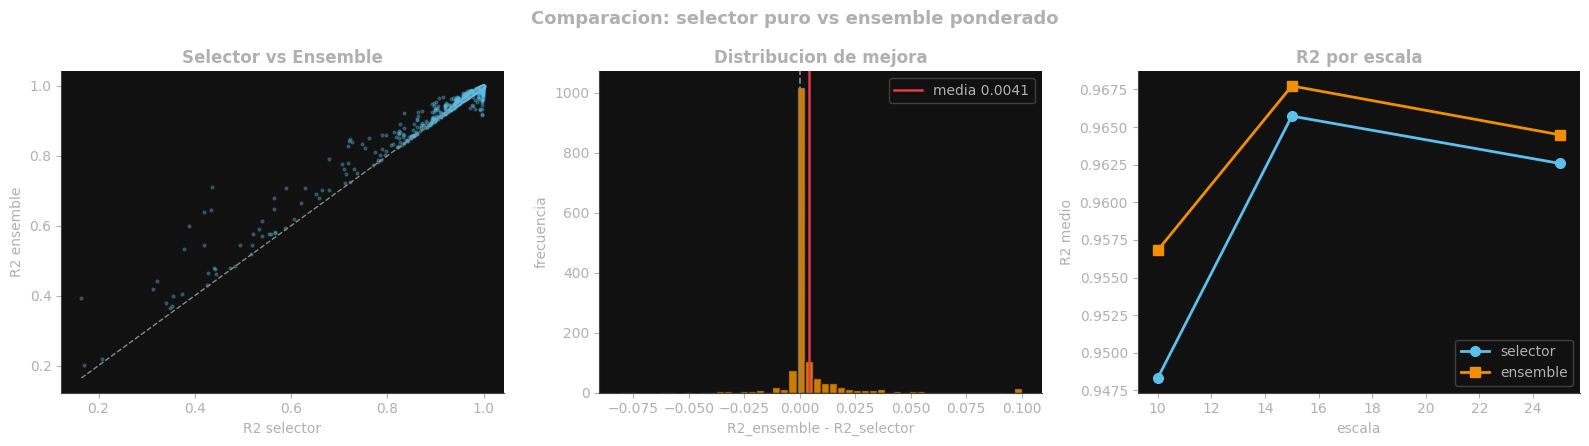

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
lo = min(df_comp['r2'].min(), df_comp['r2_ens'].min())
hi = max(df_comp['r2'].max(), df_comp['r2_ens'].max())
ax.scatter(df_comp['r2'], df_comp['r2_ens'], s=4, alpha=0.3, color=AZUL)
ax.plot([lo, hi], [lo, hi], color='#888', lw=1, linestyle='--')
ax.set_xlabel('R2 selector'); ax.set_ylabel('R2 ensemble')
ax.set_title('Selector vs Ensemble', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
ax.hist(df_comp['mejora'].clip(-0.1, 0.1), bins=50, color=NARANJ, alpha=0.85, edgecolor='#111')
ax.axvline(0, color='#888', lw=1.2, linestyle='--')
ax.axvline(df_comp['mejora'].mean(), color=ROJO, lw=1.8,
           label=f'media {df_comp["mejora"].mean():.4f}')
ax.set_xlabel('R2_ensemble - R2_selector'); ax.set_ylabel('frecuencia')
ax.set_title('Distribucion de mejora', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[2]
r2_sel_e = df_comp.groupby('escala')['r2'].mean()
r2_ens_e = df_comp.groupby('escala')['r2_ens'].mean()
ax.plot(r2_sel_e.index, r2_sel_e.values, 'o-', color=AZUL, lw=2, ms=7, label='selector')
ax.plot(r2_ens_e.index, r2_ens_e.values, 's-', color=NARANJ, lw=2, ms=7, label='ensemble')
ax.set_xlabel('escala'); ax.set_ylabel('R2 medio')
ax.set_title('R2 por escala', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Comparacion: selector puro vs ensemble ponderado', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

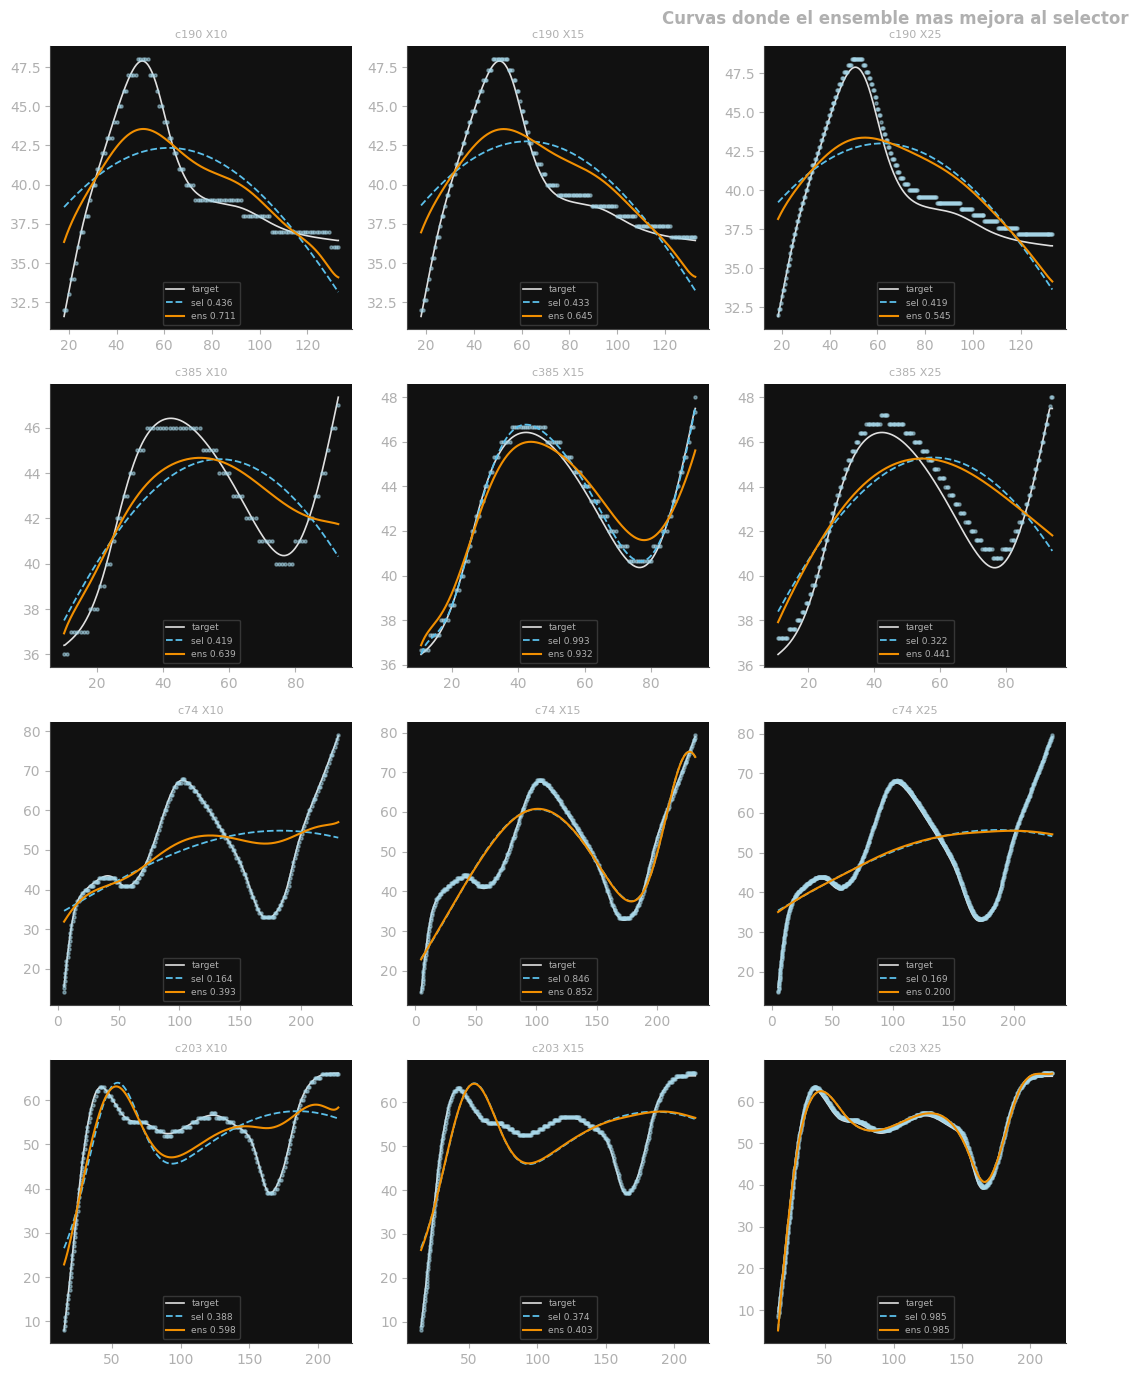

In [12]:
DEMO_IDS = df_comp.groupby('curva')['mejora'].mean().nlargest(4).index.tolist()

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
for row_idx, cid in enumerate(DEMO_IDS):
    for col_idx, esc in enumerate(ESCALAS):
        ax = axes[row_idx, col_idx]
        try:
            rec1 = reconstruir_pixel(cid, esc)
            rec2 = reconstruir_ensemble(cid, esc)
            pix  = leer_pixel_real(cid, esc)
            ax.plot(rec1['x_eval'], rec1['y_tgt'], color='#e0e0e0', lw=1.2, label='target', zorder=2)
            ax.scatter(pix['x'], pix['y'], s=5, color=PAL, alpha=0.5, zorder=3)
            ax.plot(rec1['x_eval'], rec1['y_hat'], color=AZUL, lw=1.3,
                    label=f'sel {rec1["r2"]:.3f}', linestyle='--', zorder=4)
            ax.plot(rec2['x_eval'], rec2['y_ens'], color=NARANJ, lw=1.5,
                    label=f'ens {rec2["r2_ens"]:.3f}', zorder=5)
            ax.set_title(f'c{cid} X{esc}', fontsize=8)
            ax.legend(fontsize=6.5, framealpha=0.2, loc='lower center')
        except Exception:
            ax.set_visible(False)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Curvas donde el ensemble mas mejora al selector',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>
3. Incertidumbre: banda de confianza entre escalas</h2>
<p style='color:#b0b0b0'>
Reconstruimos cada curva en las cinco escalas y calculamos, punto a punto, la desviacion estandar. 
Donde las escalas coinciden la banda es angosta; donde divergen se ensancha, 
senalando las zonas donde el modelo tiene menos certeza.</p>
<div style='border-left:4px solid #5BC0EB; background:rgba(91,192,235,0.08); 
color:#A8D8EA; padding:8px 14px; margin:8px 0'>
banda(x) = std( y_X10(x), y_X15(x), y_X25(x), y_X50(x), y_X100(x) )
</div>

In [13]:
def incertidumbre_por_curva(cid):
    x_common = np.linspace(0, 250, 500)
    preds = []
    for esc in ESCALAS:
        try:
            rec = reconstruir_ensemble(cid, esc)
            y_interp = np.interp(x_common, rec['x_eval'], rec['y_ens'],
                                 left=np.nan, right=np.nan)
            preds.append(y_interp)
        except Exception:
            pass
    if len(preds) < 2:
        return None
    mat   = np.vstack(preds)
    mean_ = np.nanmean(mat, axis=0)
    std_  = np.nanstd(mat, axis=0)
    tgt   = leer_target(cid)
    y_tgt = np.interp(x_common, tgt['x'].values, tgt['y'].values)
    valid = ~np.isnan(mean_)
    return {'cid': cid, 'x': x_common[valid], 'mean': mean_[valid],
            'std': std_[valid], 'y_tgt': y_tgt[valid],
            'std_mean': float(np.nanmean(std_[valid])),
            'r2_mean_pred': float(r2(y_tgt[valid], mean_[valid]))}

unc_demo = incertidumbre_por_curva(7)
print(f'Curva 7: sigma_media={unc_demo["std_mean"]:.4f}  R2={unc_demo["r2_mean_pred"]:.4f}')

Curva 7: sigma_media=0.1712  R2=0.9999


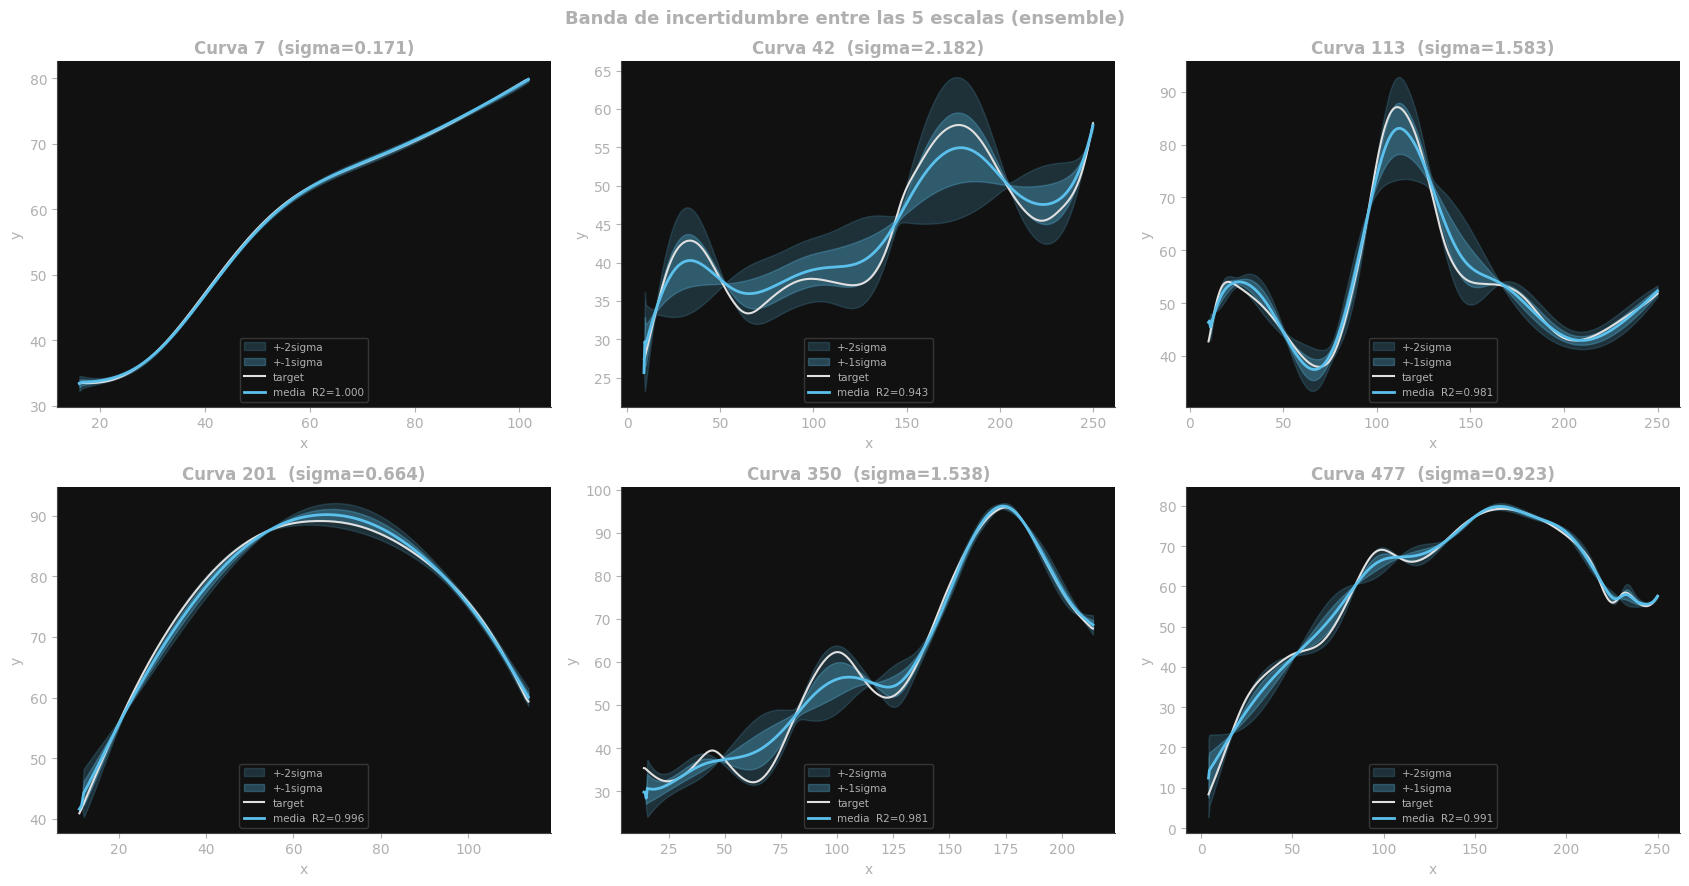

In [14]:
DEMO_UNC = [7, 42, 113, 201, 350, 477]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, cid in zip(axes.flatten(), DEMO_UNC):
    res = incertidumbre_por_curva(cid)
    if res is None:
        ax.set_visible(False); continue
    x, mu, sd, yt = res['x'], res['mean'], res['std'], res['y_tgt']
    ax.fill_between(x, mu - 2*sd, mu + 2*sd, alpha=0.18, color=AZUL, label='+-2sigma')
    ax.fill_between(x, mu - sd,   mu + sd,   alpha=0.30, color=AZUL, label='+-1sigma')
    ax.plot(x, yt, color='#e0e0e0', lw=1.5, label='target', zorder=3)
    ax.plot(x, mu, color=AZUL, lw=2, label=f'media  R2={res["r2_mean_pred"]:.3f}', zorder=4)
    ax.set_title(f'Curva {cid}  (sigma={res["std_mean"]:.3f})', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=7.5, framealpha=0.2, loc='lower center')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Banda de incertidumbre entre las 5 escalas (ensemble)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Calculando incertidumbre global en 500 curvas...
Curvas procesadas: 500
sigma medio: 0.7781
R2 medio (pred media): 0.9726


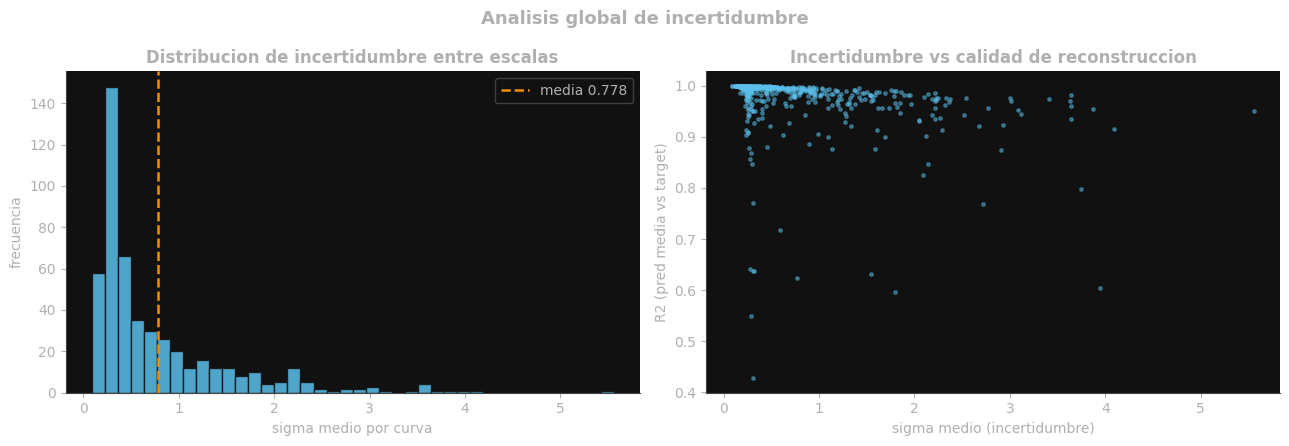

In [15]:
print('Calculando incertidumbre global en 500 curvas...')
unc_rows = []
for cid in range(1, 501):
    try:
        res = incertidumbre_por_curva(cid)
        if res:
            unc_rows.append({'curva': cid, 'std_mean': res['std_mean'], 'r2': res['r2_mean_pred']})
    except Exception:
        pass

df_unc = pd.DataFrame(unc_rows)
print(f'Curvas procesadas: {len(df_unc)}')
print(f'sigma medio: {df_unc["std_mean"].mean():.4f}')
print(f'R2 medio (pred media): {df_unc["r2"].mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(df_unc['std_mean'], bins=40, color=AZUL, alpha=0.85, edgecolor='#111')
ax.axvline(df_unc['std_mean'].mean(), color=NARANJ, lw=1.8, linestyle='--',
           label=f'media {df_unc["std_mean"].mean():.3f}')
ax.set_xlabel('sigma medio por curva'); ax.set_ylabel('frecuencia')
ax.set_title('Distribucion de incertidumbre entre escalas', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
ax.scatter(df_unc['std_mean'], df_unc['r2'], s=6, alpha=0.45, color=AZUL)
ax.set_xlabel('sigma medio (incertidumbre)'); ax.set_ylabel('R2 (pred media vs target)')
ax.set_title('Incertidumbre vs calidad de reconstruccion', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Analisis global de incertidumbre', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

<h2 style='color:#5BC0EB; font-weight:700; font-size:1.35em; margin-top:1.8em'>
4. Prueba con datos escaneados reales simulados</h2>
<p style='color:#b0b0b0'>
En la practica las curvas no vienen de archivos perfectos: se escanean desde papel, 
lo que introduce ruido no uniforme, puntos faltantes y pequenas ondulaciones. 
Simulamos ese proceso y evaluamos si el sistema sigue siendo robusto.</p>
<div style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); 
color:#e8c97a; padding:8px 14px; margin:8px 0'>
Si el sistema resiste esta degradacion extra, esta listo para usarse en un flujo de trabajo real.
</div>

In [16]:
rng = np.random.default_rng(99)

def simular_scan(cid, escala=25, sigma_noise=1.8, dropout_p=0.12, baseline_drift=True):
    dp = leer_pixel_real(cid, escala)
    x, y = dp['x'].values.copy(), dp['y'].values.copy()
    y += rng.normal(0, sigma_noise, size=len(y))
    mask_keep = rng.random(len(x)) > dropout_p
    x, y = x[mask_keep], y[mask_keep]
    if baseline_drift and len(x) > 1:
        drift_amp = rng.uniform(-2, 2)
        drift = drift_amp * np.sin(2 * np.pi * x / (x[-1] - x[0] + 1e-6))
        y += drift
    y = np.clip(y, 0, None)
    if len(x) < 10: return None
    return pd.DataFrame({'x': x, 'y': y}).sort_values('x').reset_index(drop=True)

scan_demo = simular_scan(7, escala=25)
print(f'Curva 7 escaneada: {len(scan_demo)} pts (vs {len(leer_pixel_real(7,25))} originales)')

Curva 7 escaneada: 194 pts (vs 216 originales)


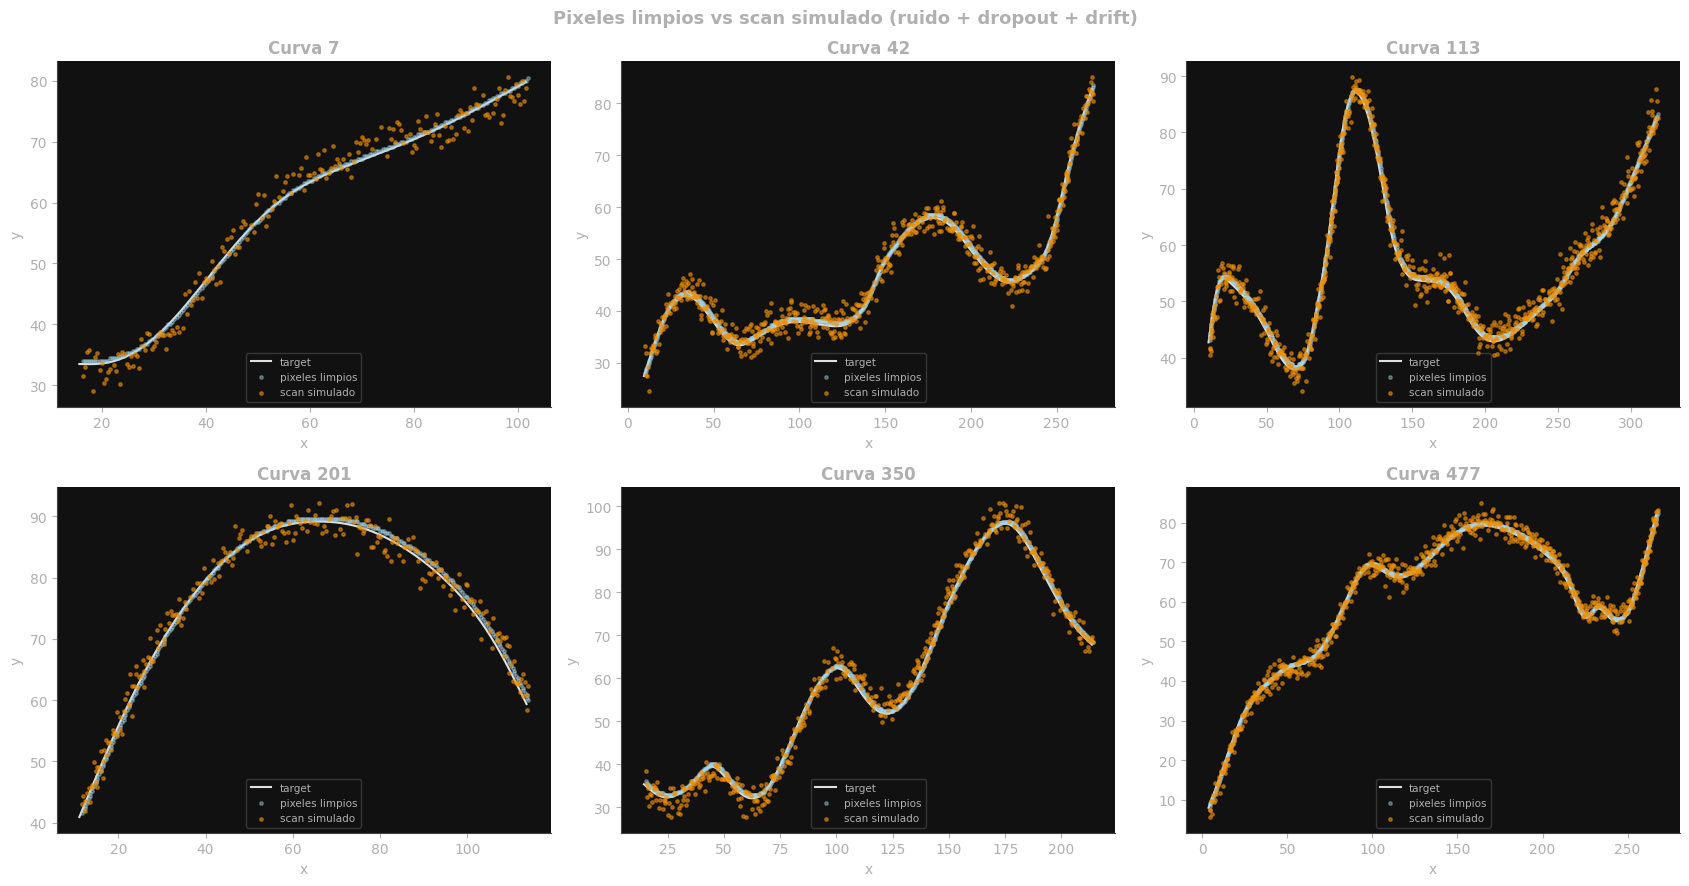

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
DEMO_SCAN = [7, 42, 113, 201, 350, 477]

for ax, cid in zip(axes.flatten(), DEMO_SCAN):
    scan = simular_scan(cid, escala=25)
    if scan is None:
        ax.set_visible(False); continue
    tgt = leer_target(cid)
    pix = leer_pixel_real(cid, 25)
    ax.plot(tgt['x'], tgt['y'], color='#e0e0e0', lw=1.5, label='target', zorder=2)
    ax.scatter(pix['x'], pix['y'], s=6, color=PAL, alpha=0.4, label='pixeles limpios', zorder=3)
    ax.scatter(scan['x'], scan['y'], s=6, color=NARANJ, alpha=0.55, label='scan simulado', zorder=4)
    ax.set_title(f'Curva {cid}', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=7.5, framealpha=0.2, loc='lower center')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Pixeles limpios vs scan simulado (ruido + dropout + drift)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def reconstruir_scan(cid, escala=25, **scan_kw):
    scan = simular_scan(cid, escala=escala, **scan_kw)
    if scan is None: return None
    tgt    = leer_target(cid)
    xp, yp = scan['x'].values, scan['y'].values
    x_eval = np.linspace(xp.min(), xp.max(), 300)
    _, probs = predecir_metodo_pixel(xp, yp)
    classes_order = pipe_new.classes_
    prob_map = {c: p for c, p in zip(classes_order, probs)}
    y_ens = np.zeros(300)
    for metodo, fitter in FITTERS.items():
        w = prob_map.get(metodo, 0.0)
        if w < 1e-6: continue
        try:
            y_ens += w * fitter(xp, yp, x_eval)
        except Exception:
            pass
    y_tgt = np.interp(x_eval, tgt['x'].values, tgt['y'].values)
    return {'x_eval': x_eval, 'y_ens': y_ens, 'y_tgt': y_tgt,
            'r2': float(r2(y_tgt, y_ens)), 'scan': scan}

print('Evaluando 500 curvas con datos escaneados...')
results_scan = []
for cid in range(1, 501):
    try:
        rec = reconstruir_scan(cid)
        if rec:
            results_scan.append({'curva': cid, 'r2_scan': rec['r2']})
    except Exception:
        pass

df_scan = pd.DataFrame(results_scan)
fallos_scan = (df_scan['r2_scan'] < 0).sum()
print(f'R2 medio con scan: {df_scan["r2_scan"].mean():.4f}')
print(f'Fallos (R2<0):     {fallos_scan} ({fallos_scan/len(df_scan)*100:.2f}%)')

Evaluando 500 curvas con datos escaneados...


In [ ]:
r2_clean   = df_comp[df_comp['escala']==25].groupby('curva')['r2_ens'].mean()
df_fcomp   = df_scan.set_index('curva').join(r2_clean.rename('r2_clean'), how='inner')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(df_fcomp['r2_clean'].clip(-0.5, 1), bins=40, color=AZUL,
        alpha=0.7, edgecolor='#111', label=f'pixeles ({df_fcomp["r2_clean"].mean():.4f})')
ax.hist(df_fcomp['r2_scan'].clip(-0.5, 1), bins=40, color=NARANJ,
        alpha=0.6, edgecolor='#111', label=f'scan ({df_fcomp["r2_scan"].mean():.4f})')
ax.axvline(df_fcomp['r2_clean'].mean(), color=AZUL,   lw=1.5, linestyle='--')
ax.axvline(df_fcomp['r2_scan'].mean(),  color=NARANJ, lw=1.5, linestyle='--')
ax.set_xlabel('R2'); ax.set_ylabel('frecuencia')
ax.set_title('Distribucion de R2: pixeles vs scan', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
ax.scatter(df_fcomp['r2_clean'], df_fcomp['r2_scan'], s=5, alpha=0.4, color=AZUL)
lo = min(df_fcomp['r2_clean'].min(), df_fcomp['r2_scan'].min())
ax.plot([lo, 1.0], [lo, 1.0], color='#888', lw=1.2, linestyle='--')
ax.set_xlabel('R2 pixeles limpios'); ax.set_ylabel('R2 scan simulado')
ax.set_title('Impacto del ruido de escaneo', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Robustez del sistema ante datos de imagen escaneada', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
DEMO_FINAL = [7, 42, 113, 201, 350, 477]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, cid in zip(axes.flatten(), DEMO_FINAL):
    rec_s = reconstruir_scan(cid)
    if rec_s is None:
        ax.set_visible(False); continue
    scan = rec_s['scan']
    ax.plot(rec_s['x_eval'], rec_s['y_tgt'], color='#e0e0e0', lw=1.5, label='target', zorder=2)
    ax.scatter(scan['x'], scan['y'], s=5, color=NARANJ, alpha=0.5, label='scan', zorder=3)
    ax.plot(rec_s['x_eval'], rec_s['y_ens'], color=AZUL, lw=2,
            label=f'ensemble R2={rec_s["r2"]:.3f}', zorder=4)
    ax.set_title(f'Curva {cid}', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=7.5, framealpha=0.2, loc='lower center')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Reconstruccion ensemble sobre datos escaneados simulados',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()